# 03.7a - Sparse excitation (hBN) - generate data

Data-generation half of `03.7 - sparse excitation hbn - organized sweep.ipynb`. This notebook
runs every ptychography reconstruction in the sweep -- 16 L1-grid cells, 7 group-sparsity
calibration points, 16 grouped-sparsity-grid cells, 4 block-size cells, and 8 dose-series
cells, 51 reconstructions in total -- and pickles the raw `recon_on - recon_off` arrays into
`sparse_excitation_sweep_results/`. **This is the slow half.** The pickles from the original
run are already in that folder, so you don't need to re-run this -- only do it if you're
changing the simulation physics, the doses, or which regularization values get swept.

All plotting lives in the companion notebook, `03.7b - sparse excitation hbn - plots.ipynb`,
which only reads the `.pkl` files this notebook writes and needs no GPU, `torch`, or `quantem`
import at all -- tweak that one freely.

## Setup

In [1]:

import pickle
import time
import itertools

import numpy as np
import torch
from scipy import signal
from scipy.ndimage import zoom
from matplotlib import pyplot as plt

from stem_utils import generate_datacube

from quantem.core.datastructures import Dataset4dstem
from quantem.diffractive_imaging.dataset_models import PtychographyDatasetRaster
from quantem.diffractive_imaging.detector_models import DetectorPixelated
from quantem.diffractive_imaging.object_models import ObjectMultiplexed
from quantem.diffractive_imaging.probe_models import ProbePixelated
from quantem.diffractive_imaging.ptychography import Ptychography
from quantem.core.utils.diffractive_imaging_utils import fit_probe_circle

RESULTS_DIR = "sparse_excitation_sweep_results"
import os
os.makedirs(RESULTS_DIR, exist_ok=True)

MAIN_SWEEP_DOSE = 1e6   # dose used for the Part 1/2 grids, the block-size sweep, and Part 4/5


def dose_tag(dose):
    """Compact label for a dose value -- '1e4', '2e3', etc, matching the style already used
    for the DOSES dict below. Falls back to plain %g for values that don't reduce to a clean
    mantissa."""
    exponent = int(np.floor(np.log10(dose) + 1e-9))
    mantissa = dose / 10 ** exponent
    if np.isclose(mantissa, round(mantissa)):
        return f"{round(mantissa)}e{exponent}"
    return f"{dose:g}"



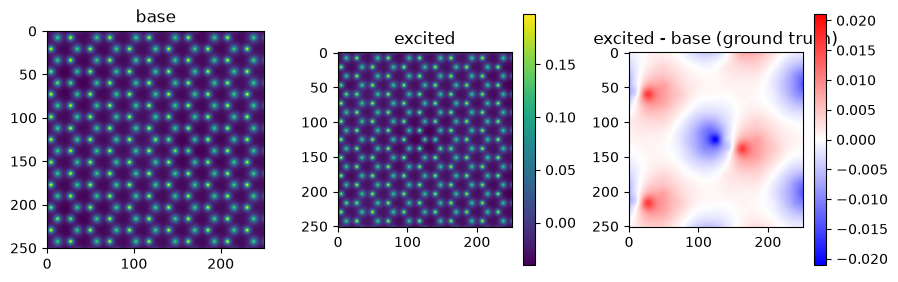

In [2]:

with open('bcenters_base_excited_phases_wide_fov.pkl', 'rb') as f:
    data = pickle.load(f)

base_phase = data['base']
excited_phase = data['excited']
x = data['x']
y = data['y']

dx = x[1] - x[0]
dy = y[1] - y[0]

plt.figure(figsize=(9, 3))
plt.subplot(1, 3, 1)
plt.imshow(base_phase)
plt.title('base')
plt.subplot(1, 3, 2)
plt.imshow(excited_phase)
plt.title('excited')
plt.colorbar()
plt.subplot(1, 3, 3)
diff_extent = np.max(np.abs(excited_phase - base_phase))
plt.imshow(excited_phase - base_phase, cmap='bwr', vmin=-diff_extent, vmax=diff_extent)
plt.title('excited - base (ground truth)')
plt.colorbar()
plt.tight_layout()
plt.show()


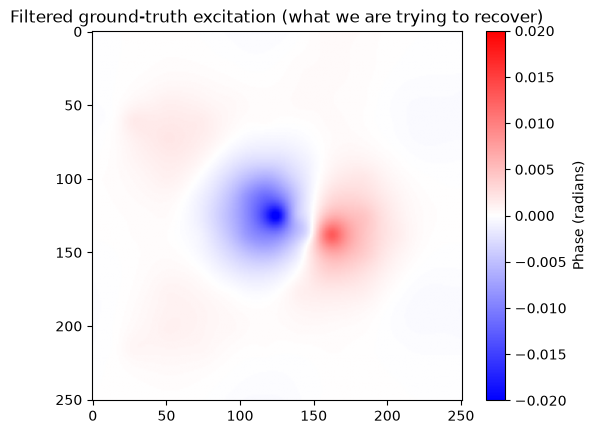

In [3]:

# same Hamming-windowed excitation used in 03.6, to taper the diff to zero at the FOV edges
window_y = np.hamming(base_phase.shape[0])
window_x = np.hamming(base_phase.shape[1])
hamming_filter = np.outer(window_y, window_x)

diff_phase = excited_phase - base_phase
filtered_diff_phase = diff_phase * hamming_filter
excited_phase = base_phase + filtered_diff_phase

plt.imshow(filtered_diff_phase, cmap='bwr', vmin=-0.02, vmax=0.02)
plt.colorbar(label='Phase (radians)')
plt.title('Filtered ground-truth excitation (what we are trying to recover)')
plt.show()


`generate_merged_scan` -- simulate + checkerboard-multiplex a base/excited datacube pair:

In [4]:

ACC_VOLTAGE     = 60e3   # eV
PROBE_SEMIANGLE = 20     # mrad
PROBE_DEFOCUS   = 30     # A
SCAN_STEP_SIZE  = 0.15   # A


def generate_merged_scan(im1, im2, x=x, y=y, dose=None, dp_trim=40, normalize=True):
    '''Simulate base/excited 4D-STEM datacubes and checkerboard-multiplex them,
    exactly as in 03.6 (dp_trim default changed to match the doses used below).'''
    meas1 = generate_datacube(
        im1, x, y,
        acc_voltage=ACC_VOLTAGE, probe_semiangle=PROBE_SEMIANGLE,
        probe_defocus=PROBE_DEFOCUS, scan_step_size=SCAN_STEP_SIZE,
    )
    meas2 = generate_datacube(
        im2, x, y,
        acc_voltage=ACC_VOLTAGE, probe_semiangle=PROBE_SEMIANGLE,
        probe_defocus=PROBE_DEFOCUS, scan_step_size=SCAN_STEP_SIZE,
    )

    if dose is not None:
        meas1 = meas1.poisson_noise(dose)
        meas2 = meas2.poisson_noise(dose)

    dcube1 = np.array(meas1.array)[:, :, dp_trim:-dp_trim, dp_trim:-dp_trim]
    dcube2 = np.array(meas2.array)[:, :, dp_trim:-dp_trim, dp_trim:-dp_trim]

    scan_mask = np.zeros(dcube2.shape[:2], dtype=np.uint8)
    xi = np.arange(scan_mask.shape[0])
    yi = np.arange(scan_mask.shape[1])
    for i in xi:
        for j in yi:
            if (i + j) % 2 == 0:
                scan_mask[i, j] = 1

    merged_scan = np.array(dcube1)
    merged_scan[scan_mask == 1, :, :] = np.array(dcube2)[scan_mask == 1, :, :]

    if normalize:
        s = merged_scan.sum(axis=(2, 3), keepdims=True)
        merged_scan = merged_scan / s

    return merged_scan.astype(np.float32), scan_mask


## Reconstruction wrapper

In [5]:

def mixed_obj_ptycho_wrapper(
    dcube,
    scan_mask,
    obj_lr=5e-3,
    probe_lr=1e-5,
    tv_weight=0.0,
    tv_channel_diff=0.0,
    channel_diff_sparcity=0.0,
    group_sparcity=0.0,
    group_block=4,
    num_iters=100,
    batch_size=2**12,
    obj_padding=64,
    plot=False,
    return_extra=False,
):
    opt_params = {
        "object": {"type": "adam", "lr": obj_lr},
        "probe": {"type": "adam", "lr": probe_lr},
    }
    scheduler_params = {
        "object": {"type": "plateau"},
        "probe": {"type": "plateau"},
    }
    constraints = {
        "object": {
            "tv_weight_xy": tv_weight,
            "tv_channel_diff": tv_channel_diff,
            "channel_diff_sparcity": channel_diff_sparcity,
            "channel_diff_group_sparcity": group_sparcity,
            "channel_diff_group_sparcity_block_size": group_block,
            "fix_potential_baseline": False,
            "identical_slices": True,
            "apply_fov_mask": False,
        },
        "probe": {
            "center_probe": False,
            "orthogonalize_probe": True,
        },
        "dataset": {
            "descan_tv_weight": 0,
            "descan_shifts_constant": False,
        },
    }

    dset = Dataset4dstem.from_array(
        dcube, name='merged_scan',
        sampling=(SCAN_STEP_SIZE, SCAN_STEP_SIZE, 1, 1),
        units=("A", "A", "pixels", "pixels"),
    )
    probe_qy0, probe_qx0, probe_R = fit_probe_circle(dset.dp_mean.array, show=False)
    dset.sampling[2] = PROBE_SEMIANGLE / probe_R
    dset.sampling[3] = PROBE_SEMIANGLE / probe_R
    dset.units[2:] = ["mrad", "mrad"]

    pdset = PtychographyDatasetRaster.from_dataset4dstem(dset)
    pdset.preprocess(
        com_fit_function="constant", plot_rotation=False, plot_com=False,
        probe_energy=ACC_VOLTAGE, force_com_rotation=0, force_com_transpose=False,
    )

    probe_params = {"energy": ACC_VOLTAGE, "defocus": PROBE_DEFOCUS, "semiangle_cutoff": PROBE_SEMIANGLE}
    detector_model = DetectorPixelated()
    probe_model = ProbePixelated.from_params(num_probes=1, probe_params=probe_params)
    obj_model = ObjectMultiplexed.from_uniform(
        num_slices=1, slice_thicknesses=1, obj_type='pure_phase',
        num_channels=2, patches_mask=torch.tensor(scan_mask),
    )
    ptycho = Ptychography.from_models(
        dset=pdset, obj_model=obj_model, probe_model=probe_model,
        detector_model=detector_model, device='cuda',
    )
    ptycho.preprocess(obj_padding_px=(obj_padding, obj_padding), batch_size=batch_size)
    ptycho.reconstruct(
        num_iters=num_iters, reset=True, autograd=True, device='cuda',
        constraints=constraints, optimizer_params=opt_params,
        scheduler_params=scheduler_params, batch_size=batch_size,
        multichannel_mode=True,
    )

    recon_off = np.angle(
        ptycho.obj_model.obj[0, 0, obj_padding:-obj_padding, obj_padding:-obj_padding]
        .detach().cpu().numpy()
    )
    recon_on = np.angle(
        ptycho.obj_model.obj[1, 0, obj_padding:-obj_padding, obj_padding:-obj_padding]
        .detach().cpu().numpy()
    )

    if plot:
        ptycho.plot_losses()
        diff = recon_on - recon_off
        diff_extent = np.max(np.abs(diff))
        plt.figure()
        plt.subplot(2, 1, 1)
        plt.imshow(recon_off, cmap='gray')
        plt.colorbar()
        plt.subplot(2, 1, 2)
        plt.imshow(diff, cmap='seismic', vmin=-diff_extent, vmax=diff_extent)
        plt.colorbar()
        plt.show()

    if return_extra:
        return recon_off, recon_on, ptycho
    return recon_off, recon_on


## Part 1 - main sweep dataset (dose = `MAIN_SWEEP_DOSE`)

One noisy checkerboard-multiplexed datacube, generated once and reused across every `(tv_channel_diff, sparsity)` combination below.

tasks:   2%|1         | 2/123 [00:02<02:50,  1.41s/it]

tasks:   2%|1         | 2/123 [00:01<01:50,  1.10it/s]

scan generated in 94.6s, shape=(161, 161, 87, 87)


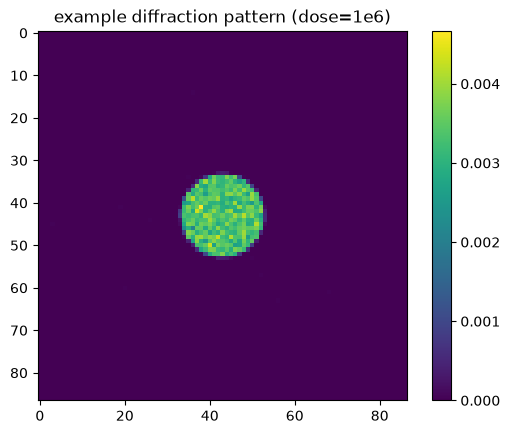

In [6]:

t0 = time.time()
scan_main, scan_mask_main = generate_merged_scan(base_phase, excited_phase, dose=MAIN_SWEEP_DOSE, dp_trim=40)
print(f"scan generated in {time.time() - t0:.1f}s, shape={scan_main.shape}")

plt.imshow(scan_main[0, 0, ...])
plt.title(f'example diffraction pattern (dose={dose_tag(MAIN_SWEEP_DOSE)})')
plt.colorbar()
plt.show()


### 1a. L1 sparsity x TV grid

In [7]:

TV_VALUES = [0.0, 25.0, 100.0, 300.0]
L1_SPARSITY_VALUES = [0.0, 5.0, 20.0, 60.0]

l1_results = {}
l1_timings = {}
for tv, sp in itertools.product(TV_VALUES, L1_SPARSITY_VALUES):
    t0 = time.time()
    recon_off, recon_on = mixed_obj_ptycho_wrapper(
        scan_main, scan_mask_main,
        tv_channel_diff=tv, channel_diff_sparcity=sp,
        num_iters=100, obj_lr=5e-3, batch_size=2**12, obj_padding=64,
    )
    dt = time.time() - t0
    l1_results[(tv, sp)] = recon_on - recon_off
    l1_timings[(tv, sp)] = dt
    print(f"tv_channel_diff={tv:g}  channel_diff_sparcity={sp:g}  ({dt:.1f}s)")

with open(f"{RESULTS_DIR}/l1_grid_dose{dose_tag(MAIN_SWEEP_DOSE)}.pkl", "wb") as f:
    pickle.dump({
        "results": l1_results, "tv": TV_VALUES, "sp": L1_SPARSITY_VALUES, "dose": MAIN_SWEEP_DOSE,
    }, f)


Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

/workspace/quantem_light_enhanced/quantem/src/quantem/diffractive_imaging/object_models.py:1305: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/Copy.cpp:307.)
  post_constraint_obj[ch] = self.apply_hard_constraints(


  0%|          | 0/100 [00:00<?, ?it/s]

tv_channel_diff=0  channel_diff_sparcity=0  (44.6s)


...

tv_channel_diff=300  channel_diff_sparcity=20  (45.4s)


Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

tv_channel_diff=300  channel_diff_sparcity=60  (68.2s)


## Part 2 - grouped sparsity

In [8]:

calib_weights = [0.0, 0.5, 1.0, 3.0, 10.0, 30.0, 100.0]
calib_rows = []
for w in calib_weights:
    t0 = time.time()
    recon_off, recon_on = mixed_obj_ptycho_wrapper(
        scan_main, scan_mask_main, group_sparcity=w, group_block=4, num_iters=40,
    )
    diff = recon_on - recon_off
    calib_rows.append((w, np.mean(np.abs(diff)), diff.std(), np.abs(diff).max(), time.time() - t0))
    print(f"group_sparcity={w:6g}  mean|diff|={calib_rows[-1][1]:.5f}  std={calib_rows[-1][2]:.5f}  max|diff|={calib_rows[-1][3]:.5f}  ({calib_rows[-1][4]:.1f}s)")


Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/40 [00:00<?, ?it/s]

group_sparcity=     0  mean|diff|=0.00207  std=0.00251  max|diff|=0.01152  (29.1s)


Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


...

group_sparcity=    30  mean|diff|=0.00115  std=0.00146  max|diff|=0.00686  (29.7s)


Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/40 [00:00<?, ?it/s]

group_sparcity=   100  mean|diff|=0.00068  std=0.00085  max|diff|=0.00382  (29.5s)


*(Grid weights below were chosen after inspecting the calibration printout above, to span the same no-effect -> strongly-suppressed range that the L1 sweep covers.)*

In [9]:

GROUP_SPARSITY_VALUES = [0.0, 3.0, 15.0, 50.0]
GROUP_BLOCK_SIZE = 4

group_results = {}
group_timings = {}
for tv, gw in itertools.product(TV_VALUES, GROUP_SPARSITY_VALUES):
    t0 = time.time()
    recon_off, recon_on = mixed_obj_ptycho_wrapper(
        scan_main, scan_mask_main,
        tv_channel_diff=tv, group_sparcity=gw, group_block=GROUP_BLOCK_SIZE,
        num_iters=100, obj_lr=5e-3, batch_size=2**12, obj_padding=64,
    )
    dt = time.time() - t0
    group_results[(tv, gw)] = recon_on - recon_off
    group_timings[(tv, gw)] = dt
    print(f"tv_channel_diff={tv:g}  channel_diff_group_sparcity={gw:g}  ({dt:.1f}s)")

with open(f"{RESULTS_DIR}/group_grid_dose{dose_tag(MAIN_SWEEP_DOSE)}.pkl", "wb") as f:
    pickle.dump({
        "results": group_results, "tv": TV_VALUES, "gw": GROUP_SPARSITY_VALUES,
        "block": GROUP_BLOCK_SIZE, "dose": MAIN_SWEEP_DOSE,
    }, f)


Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

tv_channel_diff=0  channel_diff_group_sparcity=0  (43.2s)


Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


...

tv_channel_diff=300  channel_diff_group_sparcity=15  (44.8s)


Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

tv_channel_diff=300  channel_diff_group_sparcity=50  (45.6s)


### 2a. Does block size matter?

In [10]:
BLOCK_SIZES = [2, 4, 8, 16]
FIXED_GROUP_WEIGHT = 15.0

block_results = {}
block_timings = {}
for b in BLOCK_SIZES:
    t0 = time.time()
    recon_off, recon_on = mixed_obj_ptycho_wrapper(
        scan_main, scan_mask_main,
        group_sparcity=FIXED_GROUP_WEIGHT, group_block=b,
        num_iters=100, obj_lr=5e-3, batch_size=2**12, obj_padding=64,
    )
    dt = time.time() - t0
    block_results[b] = recon_on - recon_off
    block_timings[b] = dt
    print(f"block_size={b}  ({dt:.1f}s)")

with open(f"{RESULTS_DIR}/group_block_size_sweep_dose{dose_tag(MAIN_SWEEP_DOSE)}.pkl", "wb") as f:
    pickle.dump({
        "results": block_results, "block_sizes": BLOCK_SIZES, "weight": FIXED_GROUP_WEIGHT,
        "dose": MAIN_SWEEP_DOSE,
    }, f)
print(f"saved group_block_size_sweep_dose{dose_tag(MAIN_SWEEP_DOSE)}.pkl")

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

block_size=2  (44.3s)


Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


...

block_size=8  (44.6s)


Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/100 [00:00<?, ?it/s]

block_size=16  (44.4s)
saved group_block_size_sweep_dose1e6.pkl


## Part 3 - dose series across doses

Two regularization picks from the Part 1 grid (mild, strong), each re-run at four doses (noiseless, `MAIN_SWEEP_DOSE`, 1e4, 2e3) -- the `MAIN_SWEEP_DOSE` cell is reused directly from the Part 1 grid above.

In [11]:

REG_PICKS = {
    'mild (tv=100, sp=20)': (100.0, 20.0),
    'strong (tv=300, sp=60)': (300.0, 60.0),
}

MAIN_SWEEP_LABEL = f'{dose_tag(MAIN_SWEEP_DOSE)} (main sweep)'

DOSES = {
    'noiseless': None,
    MAIN_SWEEP_LABEL: MAIN_SWEEP_DOSE,
    '1e4': 1e4,
    '2e3': 2e3,
}

dose_diffs = {pick_label: {} for pick_label in REG_PICKS}
for pick_label, (tv, sp) in REG_PICKS.items():
    dose_diffs[pick_label][MAIN_SWEEP_LABEL] = l1_results[(tv, sp)]

for pick_label, (tv, sp) in REG_PICKS.items():
    for label, dose in DOSES.items():
        if label in dose_diffs[pick_label]:
            continue
        t0 = time.time()
        scan_d, mask_d = generate_merged_scan(base_phase, excited_phase, dose=dose, dp_trim=40)
        recon_off, recon_on = mixed_obj_ptycho_wrapper(
            scan_d, mask_d,
            tv_channel_diff=tv, channel_diff_sparcity=sp,
            num_iters=150, obj_lr=5e-3, batch_size=2**12, obj_padding=64,
        )
        dose_diffs[pick_label][label] = recon_on - recon_off
        print(f"[{pick_label}] dose={label}  total time (scan+recon) = {time.time() - t0:.1f}s")

with open(f"{RESULTS_DIR}/dose_series_diffs_dose{dose_tag(MAIN_SWEEP_DOSE)}.pkl", "wb") as f:
    pickle.dump({"dose_diffs": dose_diffs, "reg_picks": REG_PICKS, "dose": MAIN_SWEEP_DOSE}, f)


tasks:   2%|1         | 2/123 [00:01<01:58,  1.02it/s]

tasks:   2%|1         | 2/123 [00:01<01:54,  1.05it/s]

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/150 [00:00<?, ?it/s]

...

tasks:   2%|1         | 2/123 [00:01<01:50,  1.10it/s]

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities:   0%|          | 0/25921 [00:00<?, ?probe position/s]

  0%|          | 0/150 [00:00<?, ?it/s]

[strong (tv=300, sp=60)] dose=2e3  total time (scan+recon) = 147.5s


## Done

Everything downstream is plotting only. Files written to `sparse_excitation_sweep_results/`:

- `l1_grid_dose{tag}.pkl` -- 16 L1-sparsity x TV cells
- `group_grid_dose{tag}.pkl` -- 16 grouped-sparsity x TV cells
- `group_block_size_sweep_dose{tag}.pkl` -- 4 block-size cells
- `dose_series_diffs_dose{tag}.pkl` -- 8 dose-series cells (2 regularization picks x 4 doses)

where `{tag}` = `dose_tag(MAIN_SWEEP_DOSE)` -- `1e5` for the default `MAIN_SWEEP_DOSE = 1e5`.

Open `03.7b - sparse excitation hbn - plots.ipynb` to regenerate every figure from these.